In [1]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [2]:
import pandas as pd
import os

# Chemin identifié d'après la liste des fichiers
drive_path = '/content/gdrive/MyDrive/Time series Projet/data'

try:
    # Importation des fichiers
    df_eco = pd.read_csv(os.path.join(drive_path, 'Morocco_cleaned.csv'))
    df_tourisme = pd.read_csv(os.path.join(drive_path, 'maroc_tourism_2030_all_arrival_sources.csv'))

    print('\nAperçu de Morocco_cleaned :')
    display(df_eco.head()) # Corrected from Morocco_cleaned

    print('\nAperçu de maroc_tourism_2030_all_arrival_sources :')
    display(df_tourisme.head()) # Corrected from maroc_tourism
except FileNotFoundError:
    print(f'Erreur : Fichiers non trouvés dans {drive_path}.')
    print('Contenu du dossier :', os.listdir(drive_path) if os.path.exists(drive_path) else 'Dossier introuvable')


Aperçu de Morocco_cleaned :


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction
0,1974-01-01,1.469000e+09,102.69609,18.65,-2.040000e+07,40.0,NaN
1,1974-02-01,1.469000e+09,102.69609,18.65,-1.824104e+07,40.0,NaN
2,1974-03-01,1.469000e+09,102.69609,18.65,-1.629101e+07,40.0,NaN
3,1974-04-01,1.469000e+09,102.69609,18.65,-1.413205e+07,40.0,NaN
4,1974-05-01,1.469000e+09,102.69609,18.65,-1.204274e+07,40.0,NaN



Aperçu de maroc_tourism_2030_all_arrival_sources :


,Date,Year,Month,Arrivals,Arrivals_EHTC,Arrivals_WB,Nights,receipts_MHD,Recettes_Mensuelles_MDH
0,1995-01-01,1995,1,165120.0,NaN,165120.0,NaN,881.4,NaN
1,1995-02-01,1995,2,165120.0,NaN,165120.0,NaN,881.4,NaN
2,1995-03-01,1995,3,220160.0,NaN,220160.0,NaN,1175.2,NaN
3,1995-04-01,1995,4,247680.0,NaN,247680.0,NaN,1322.1,NaN
4,1995-05-01,1995,5,247680.0,NaN,247680.0,NaN,1322.1,NaN


In [3]:
df_tourisme = df_tourisme.drop(columns=['Arrivals_EHTC', 'Arrivals_WB'])
df_tourisme['Total_Receipts_MDH'] = df_tourisme['receipts_MHD'].fillna(df_tourisme['Recettes_Mensuelles_MDH'])
df_tourisme['Total_Receipts_MDH'] = df_tourisme['Recettes_Mensuelles_MDH'].fillna(df_tourisme['receipts_MHD'])
df_tourisme = df_tourisme.drop(columns=['receipts_MHD', 'Recettes_Mensuelles_MDH'])
print("Fusion des colonnes de recettes terminée.")
display(df_tourisme.head())
display(df_tourisme.info())

Fusion des colonnes de recettes terminée.


,Date,Year,Month,Arrivals,Nights,Total_Receipts_MDH
0,1995-01-01,1995,1,165120.0,NaN,881.4
1,1995-02-01,1995,2,165120.0,NaN,881.4
2,1995-03-01,1995,3,220160.0,NaN,1175.2
3,1995-04-01,1995,4,247680.0,NaN,1322.1
4,1995-05-01,1995,5,247680.0,NaN,1322.1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                384 non-null    object 
 1   Year                384 non-null    int64  
 2   Month               384 non-null    int64  
 3   Arrivals            350 non-null    float64
 4   Nights              49 non-null     float64
 5   Total_Receipts_MDH  336 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 18.1+ KB


None

In [4]:
import pandas as pd

# Utilisation des DataFrames chargés précédemment
hotel_bookings = df_eco.copy()
hospitality_benchmark = df_tourisme.copy()

# Convert 'Date' columns to datetime objects
hotel_bookings['Date'] = pd.to_datetime(hotel_bookings['Date'])
hospitality_benchmark['Date'] = pd.to_datetime(hospitality_benchmark['Date'])

# Filter datasets for the period 1995-2026
start_date = '1995-01-01'
end_date = '2026-04-01'

hotel_bookings_filtered = hotel_bookings[(hotel_bookings['Date'] >= start_date) & (hotel_bookings['Date'] <= end_date)]
hospitality_benchmark_filtered = hospitality_benchmark[(hospitality_benchmark['Date'] >= start_date) & (hospitality_benchmark['Date'] <= end_date)]

# Merge the two filtered datasets on the 'Date' column
merged_df = pd.merge(hotel_bookings_filtered, hospitality_benchmark_filtered, on='Date', how='outer')

print(f"\nDatasets merged successfully for the period {start_date} to {end_date}.")
print(f"Shape of the merged dataset: {merged_df.shape}")
print("Aperçu du dataset fusionné :")
display(merged_df.head())
display(merged_df.tail())


Datasets merged successfully for the period 1995-01-01 to 2026-04-01.
Shape of the merged dataset: (376, 12)
Aperçu du dataset fusionné :


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Arrivals,Nights,Total_Receipts_MDH
0,1995-01-01,1.469000e+09,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,165120.0,NaN,881.4
1,1995-02-01,1.501953e+09,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,165120.0,NaN,881.4
2,1995-03-01,1.531718e+09,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,220160.0,NaN,1175.2
3,1995-04-01,1.564671e+09,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,247680.0,NaN,1322.1
4,1995-05-01,1.596562e+09,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,247680.0,NaN,1322.1


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Arrivals,Nights,Total_Receipts_MDH
371,2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,1772000.0,3617000.0,6905.05
372,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,1,1305000.0,3309000.0,NaN
373,2026-02-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,2,1373000.0,2993000.0,NaN
374,2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,3,1597000.0,NaN,NaN
375,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,4,NaN,NaN,NaN


In [5]:
merged_df = merged_df.drop('InterTourismeReceipts', axis=1, errors='ignore')
merged_df.head()

,Date,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Arrivals,Nights,Total_Receipts_MDH
0,1995-01-01,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,165120.0,NaN,881.4
1,1995-02-01,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,165120.0,NaN,881.4
2,1995-03-01,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,220160.0,NaN,1175.2
3,1995-04-01,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,247680.0,NaN,1322.1
4,1995-05-01,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,247680.0,NaN,1322.1


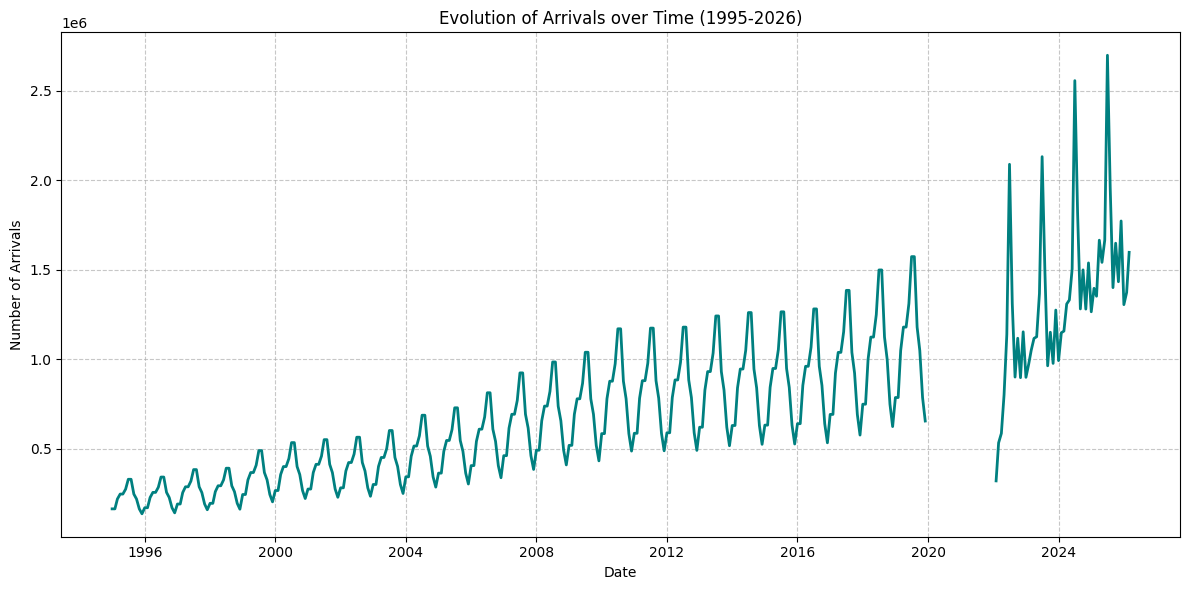

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(merged_df['Date'], merged_df['Arrivals'], color='teal', linewidth=2)
plt.title('Evolution of Arrivals over Time (1995-2026)')
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import io

# 1. Création des données COVID fournies
covid_csv = """Annee,Mois,Arrivees,Recettes_Mrd_MAD
2020,Janvier,850000,6.5
2020,Fevrier,780000,5.8
2020,Mars,320000,3.2
2020,Avril,0,0.4
2020,Mai,0,0.3
2020,Juin,0,0.3
2020,Juillet,20000,0.8
2020,Aout,60000,1.2
2020,Septembre,80000,2.1
2020,Octobre,120000,3.1
2020,Novembre,150000,3.5
2020,Decembre,200000,4.2
2021,Janvier,100000,2.5
2021,Fevrier,90000,2.1
2021,Mars,110000,2.4
2021,Avril,130000,2.8
2021,Mai,150000,3.1
2021,Juin,450000,4.5
2021,Juillet,800000,7.2
2021,Aout,950000,8.4
2021,Septembre,350000,4.8
2021,Octobre,380000,5.1
2021,Novembre,120000,2.9
2021,Decembre,80000,1.8"""

df_covid = pd.read_csv(io.StringIO(covid_csv))

# 2. Mapping des mois français en chiffres
mois_map = {
    'Janvier': 1, 'Fevrier': 2, 'Mars': 3, 'Avril': 4, 'Mai': 5, 'Juin': 6,
    'Juillet': 7, 'Aout': 8, 'Septembre': 9, 'Octobre': 10, 'Novembre': 11, 'Decembre': 12
}
df_covid['Month_Num'] = df_covid['Mois'].map(mois_map)

# 3. Création de la colonne Date et préparation des colonnes
df_covid['Date'] = pd.to_datetime(df_covid[['Annee', 'Month_Num']].assign(Day=1).rename(columns={'Annee': 'year', 'Month_Num': 'month'}))
df_covid['is_covid'] = 1
df_covid['Total_Receipts_MDH'] = df_covid['Recettes_Mrd_MAD'] * 1000
df_covid = df_covid.rename(columns={'Arrivees': 'Arrivals'})

# 4. Intégration dans merged_df
# On ajoute is_covid à merged_df (initialement 0)
merged_df['is_covid'] = 0

# Fusion/Mise à jour : on utilise les données COVID pour écraser les valeurs existantes sur ces dates
merged_df.set_index('Date', inplace=True)
df_covid.set_index('Date', inplace=True)

# Mise à jour des colonnes Arrivals, Total_Receipts_MDH et is_covid
merged_df.update(df_covid[['Arrivals', 'Total_Receipts_MDH', 'is_covid']])

merged_df.reset_index(inplace=True)

print("Données COVID intégrées avec succès.")
display(merged_df[(merged_df['Date'] >= '2020-01-01') & (merged_df['Date'] <= '2021-12-01')].head())

Données COVID intégrées avec succès.


,Date,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Arrivals,Nights,Total_Receipts_MDH,is_covid
300,2020-01-01,101.584440,67.770000,1.418713e+09,5.400000,NaN,2020,1,850000.0,NaN,6500.0,1
301,2020-02-01,101.719699,49.783187,1.490321e+09,5.383060,NaN,2020,2,780000.0,NaN,5800.0,1
302,2020-03-01,101.846231,32.956813,1.557309e+09,5.367213,NaN,2020,3,320000.0,NaN,3200.0,1
303,2020-04-01,101.981490,14.970000,1.628917e+09,5.350273,NaN,2020,4,0.0,NaN,400.0,1
304,2020-05-01,102.112385,18.490000,1.698215e+09,5.333880,NaN,2020,5,0.0,NaN,300.0,1


In [8]:
# Interpolating all NaN values in the Arrivals column
merged_df['Arrivals'] = merged_df['Arrivals'].interpolate(method='linear')

# Checking if there are any NaN values left in Arrivals
missing_after = merged_df['Arrivals'].isna().sum()
print(f"Nombre de valeurs manquantes restantes dans 'Arrivals' : {missing_after}")

# Displaying the first few rows to verify
display(merged_df[['Date', 'Arrivals']].head())

Nombre de valeurs manquantes restantes dans 'Arrivals' : 0


,Date,Arrivals
0,1995-01-01,165120.0
1,1995-02-01,165120.0
2,1995-03-01,220160.0
3,1995-04-01,247680.0
4,1995-05-01,247680.0


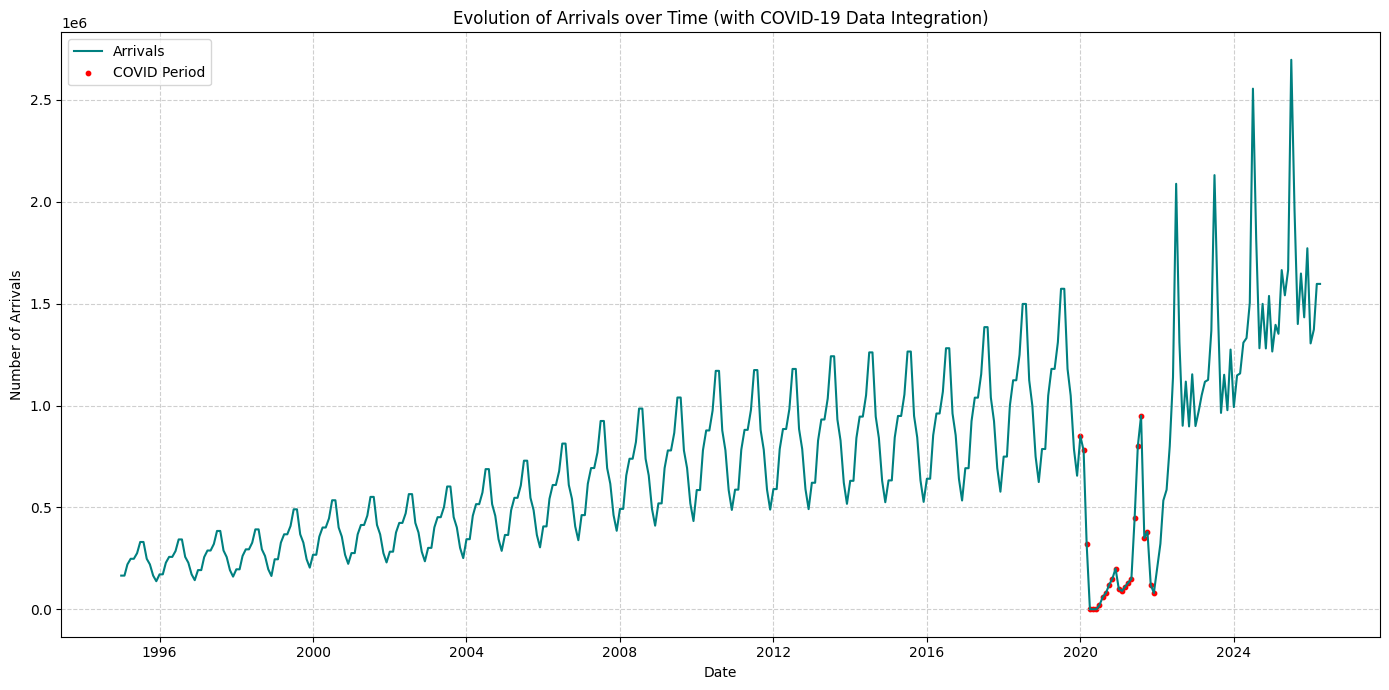

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(merged_df['Date'], merged_df['Arrivals'], color='teal', label='Arrivals')

# Highlight the COVID period where is_covid == 1
covid_period = merged_df[merged_df['is_covid'] == 1]
plt.scatter(covid_period['Date'], covid_period['Arrivals'], color='red', s=10, label='COVID Period')

plt.title('Evolution of Arrivals over Time (with COVID-19 Data Integration)')
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Dataset complet sauvegarde dans full_tourisme_data.csv


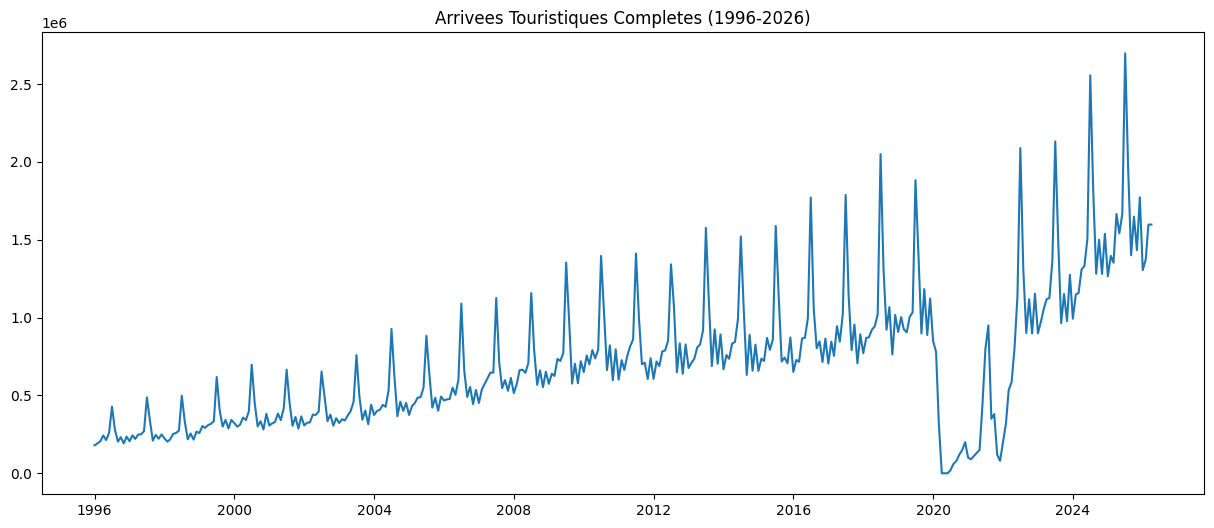

,Date,Arrivals
0,1996-01-01,179818.264181
1,1996-02-01,191882.055874
2,1996-03-01,205551.400025
3,1996-04-01,242965.696872
4,1996-05-01,213536.873098


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraire la saisonnalite et le bruit (2022-2026)
df_recent = merged_df[(merged_df['Date'] >= '2022-01-01') & (merged_df['Date'] <= '2026-04-01')].copy()
df_recent.set_index('Date', inplace=True)
decomp_recent = seasonal_decompose(df_recent['Arrivals'], model='multiplicative', period=12)
seasonal_pattern = decomp_recent.seasonal.groupby(decomp_recent.seasonal.index.month).mean()
seasonal_pattern = seasonal_pattern / seasonal_pattern.sum() * 12
residual_std = decomp_recent.resid.std()

# 2. Preparer l'historique (1996-2019)
df_hist = merged_df[(merged_df['Date'] >= '1996-01-01') & (merged_df['Date'] <= '2019-12-31')].copy()
df_annual = df_hist.groupby(df_hist['Date'].dt.year)['Arrivals'].sum().reset_index()
df_annual.columns = ['Year_Ref', 'Annual_Total']

# Fusion correcte sur l'annee
df_hist['Year_Match'] = df_hist['Date'].dt.year
df_hist = df_hist.merge(df_annual, left_on='Year_Match', right_on='Year_Ref')

def reconstruct_monthly(row):
    month = row['Date'].month
    base_monthly_avg = row['Annual_Total'] / 12.0
    noise_factor = np.random.normal(1.0, residual_std)
    return base_monthly_avg * seasonal_pattern[month] * noise_factor

df_hist['Arrivals_Simulated'] = df_hist.apply(reconstruct_monthly, axis=1)

# 3. Merge avec 2020-2026
df_hist_final = df_hist[['Date', 'Arrivals_Simulated']].rename(columns={'Arrivals_Simulated': 'Arrivals'})
df_recent_final = merged_df[merged_df['Date'] >= '2020-01-01'][['Date', 'Arrivals']]

full_tourisme_data = pd.concat([df_hist_final, df_recent_final], axis=0).sort_values('Date').reset_index(drop=True)

# 4. Sauvegarde
full_tourisme_data.to_csv('full_tourisme_data.csv', index=False)
print("Dataset complet sauvegarde dans full_tourisme_data.csv")

plt.figure(figsize=(15, 6))
plt.plot(full_tourisme_data['Date'], full_tourisme_data['Arrivals'])
plt.title('Arrivees Touristiques Completes (1996-2026)')
plt.show()
display(full_tourisme_data.head())

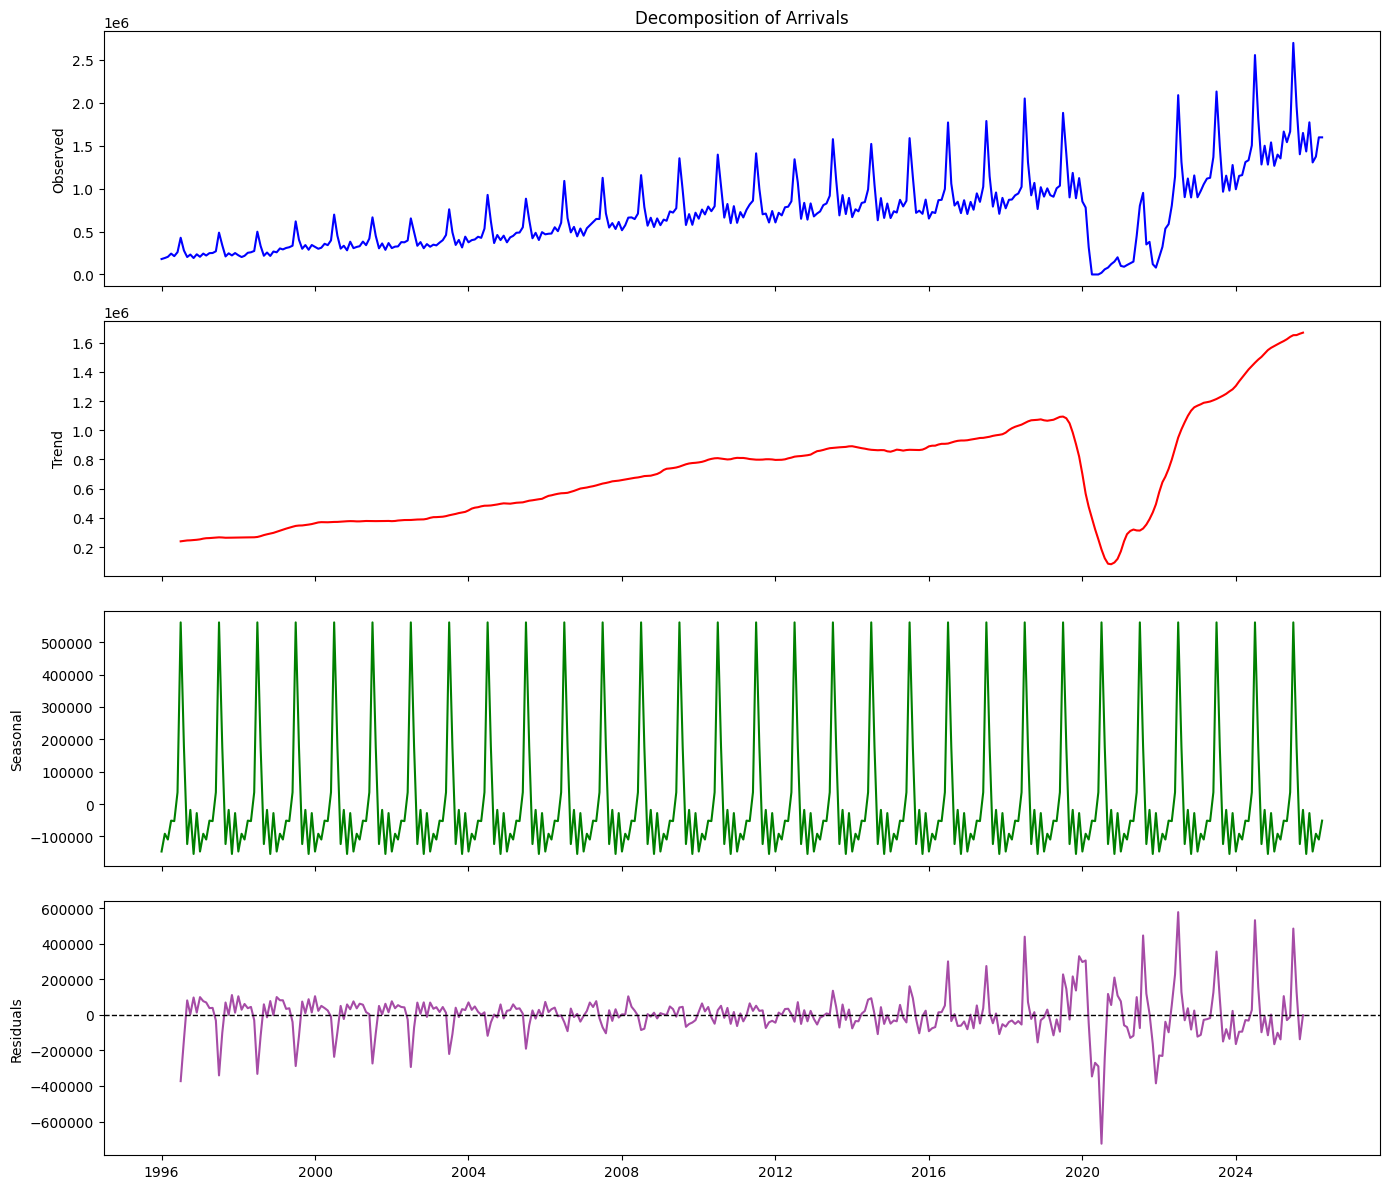

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Preparation des donnees
decomp_data = full_tourisme_data[['Date', 'Arrivals']].copy()
decomp_data['Date'] = pd.to_datetime(decomp_data['Date'])
decomp_data.set_index('Date', inplace=True)
decomp_data['Arrivals'] = decomp_data['Arrivals'].interpolate(method='linear')

# Decomposition
decomposition = seasonal_decompose(decomp_data['Arrivals'], model='additive', period=12)

# Custom Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Observed
ax1.plot(decomposition.observed, color='blue')
ax1.set_ylabel('Observed')
ax1.set_title('Decomposition of Arrivals')

# Trend
ax2.plot(decomposition.trend, color='red')
ax2.set_ylabel('Trend')

# Seasonal
ax3.plot(decomposition.seasonal, color='green')
ax3.set_ylabel('Seasonal')

# Residuals (Back to line plot as requested)
ax4.plot(decomposition.resid.index, decomposition.resid, color='purple', alpha=0.7)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [12]:
# Identify common values in the 'Arrivals' column between merged_df and full_tourisme_data
arrivals_merged = set(merged_df['Arrivals'].dropna())
arrivals_full = set(full_tourisme_data['Arrivals'].dropna())

common_arrivals = arrivals_merged.intersection(arrivals_full)

print(f"Number of common arrival values: {len(common_arrivals)}")
print("First 10 common values:")
print(list(common_arrivals)[:10])

Number of common arrival values: 70
First 10 common values:
[320000.0, 0.0, 80000.0, 800000.0, 899329.0, 897408.0, 1157507.0, 1648000.0, 1280138.0, 533772.0]


In [13]:
import pandas as pd
import numpy as np

# 1. Utilisation de merged_df comme base (contient Oil_price, FDI, REER, etc.)
final_full_df = merged_df.copy()

# 2. Remplacement de la colonne Arrivals par les données complètes (1996-2026)
# On retire l'ancienne colonne Arrivals qui contient des NaNs
if 'Arrivals' in final_full_df.columns:
    final_full_df = final_full_df.drop(columns=['Arrivals'])

# Fusion avec full_tourisme_data
final_full_df = pd.merge(final_full_df, full_tourisme_data[['Date', 'Arrivals']], on='Date', how='left')

# 3. Nettoyage : Interpolation pour les quelques dates de 1995 non couvertes par full_tourisme_data
final_full_df['Arrivals'] = final_full_df['Arrivals'].interpolate(method='linear').bfill()

print("Fusion terminée : full_tourisme_data a été intégré dans final_full_df.")
print(f"Nombre de valeurs manquantes dans Arrivals : {final_full_df['Arrivals'].isna().sum()}")

display(final_full_df.head())
display(final_full_df.tail())

Fusion terminée : full_tourisme_data a été intégré dans final_full_df.
Nombre de valeurs manquantes dans Arrivals : 0


,Date,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,Total_Receipts_MDH,is_covid,Arrivals
0,1995-01-01,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,NaN,881.4,0,179818.264181
1,1995-02-01,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,NaN,881.4,0,179818.264181
2,1995-03-01,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,NaN,1175.2,0,179818.264181
3,1995-04-01,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,NaN,1322.1,0,179818.264181
4,1995-05-01,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,NaN,1322.1,0,179818.264181


,Date,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,Total_Receipts_MDH,is_covid,Arrivals
371,2025-12-01,NaN,NaN,NaN,NaN,NaN,2025,12,3617000.0,6905.05,0,1772000.0
372,2026-01-01,NaN,NaN,NaN,NaN,NaN,2026,1,3309000.0,NaN,0,1305000.0
373,2026-02-01,NaN,NaN,NaN,NaN,NaN,2026,2,2993000.0,NaN,0,1373000.0
374,2026-03-01,NaN,NaN,NaN,NaN,NaN,2026,3,NaN,NaN,0,1597000.0
375,2026-04-01,NaN,NaN,NaN,NaN,NaN,2026,4,NaN,NaN,0,1597000.0


In [14]:
import pandas as pd

# Ensure merged_df is available from the previous valid state
# Based on cell oNSOYDu_smVn and subsequent filters
hotel_bookings = df_eco.copy()
hospitality_benchmark = df_tourisme.copy()
hotel_bookings['Date'] = pd.to_datetime(hotel_bookings['Date'])
hospitality_benchmark['Date'] = pd.to_datetime(hospitality_benchmark['Date'])

# Re-filtering and merging to ensure the base variable exists
merged_df = pd.merge(
    hotel_bookings[(hotel_bookings['Date'] >= '1995-01-01') & (hotel_bookings['Date'] <= '2026-04-01')],
    hospitality_benchmark[(hospitality_benchmark['Date'] >= '1995-01-01') & (hospitality_benchmark['Date'] <= '2026-04-01')],
    on='Date', how='outer'
)

# Set indicator for covid
merged_df['is_covid'] = 0
merged_df.loc[(merged_df['Date'] >= '2020-01-01') & (merged_df['Date'] <= '2021-12-01'), 'is_covid'] = 1

# Update the Total_Receipts_MDH specifically for the COVID period from df_covid
temp_df = merged_df.copy().set_index('Date')
temp_df.update(df_covid[['Total_Receipts_MDH']])
merged_df = temp_df.reset_index()

print("Receipts for the COVID period have been successfully integrated.")
display(merged_df[(merged_df['is_covid'] == 1)].head())

Receipts for the COVID period have been successfully integrated.


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Arrivals,Nights,Total_Receipts_MDH,is_covid
300,2020-01-01,4.514000e+09,101.584440,67.770000,1.418713e+09,5.400000,NaN,2020,1,NaN,NaN,6500.0,1
301,2020-02-01,4.678232e+09,101.719699,49.783187,1.490321e+09,5.383060,NaN,2020,2,NaN,NaN,5800.0,1
302,2020-03-01,4.831869e+09,101.846231,32.956813,1.557309e+09,5.367213,NaN,2020,3,NaN,NaN,3200.0,1
303,2020-04-01,4.996101e+09,101.981490,14.970000,1.628917e+09,5.350273,NaN,2020,4,NaN,NaN,400.0,1
304,2020-05-01,5.155036e+09,102.112385,18.490000,1.698215e+09,5.333880,NaN,2020,5,NaN,NaN,300.0,1


In [15]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.0 MB/s eta 0:00:00


In [16]:
# 1. Alignement des Arrivals depuis full_tourisme_data
merged_df = pd.merge(merged_df.drop(columns=['Arrivals'], errors='ignore'),
                     full_tourisme_data[['Date', 'Arrivals']],
                     on='Date', how='left')

# 2. Mise à jour des Receipts pour la période COVID (2020-2021)
# On s'assure que merged_df utilise les valeurs de df_covid pour les recettes
merged_df.set_index('Date', inplace=True)
merged_df.update(df_covid[['Total_Receipts_MDH']])
merged_df.reset_index(inplace=True)

print("Synchronisation terminée : Arrivals et Receipts sont désormais alignés.")
display(merged_df[(merged_df['Date'] >= '2020-01-01') & (merged_df['Date'] <= '2021-12-01')][['Date', 'Arrivals', 'Total_Receipts_MDH']].head())

Synchronisation terminée : Arrivals et Receipts sont désormais alignés.


,Date,Arrivals,Total_Receipts_MDH
300,2020-01-01,850000.0,6500.0
301,2020-02-01,780000.0,5800.0
302,2020-03-01,320000.0,3200.0
303,2020-04-01,0.0,400.0
304,2020-05-01,0.0,300.0


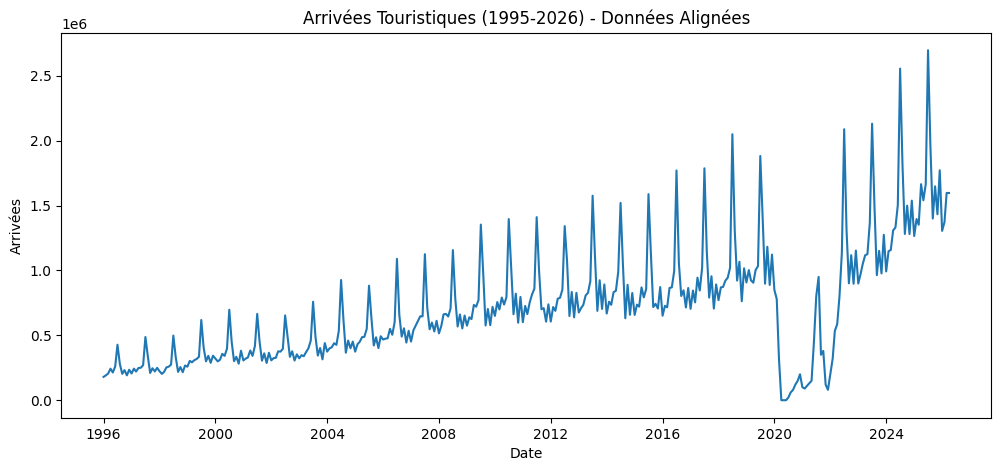

In [17]:
import matplotlib.pyplot as plt

# Utilisation du DataFrame fusionné pour garantir l'alignement des dimensions
plt.figure(figsize=(12, 5))
plt.plot(merged_df['Date'], merged_df['Arrivals'])
plt.title('Arrivées Touristiques (1995-2026) - Données Alignées')
plt.xlabel('Date')
plt.ylabel('Arrivées')
plt.show()

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure Total_Receipts_MDH is numeric and fill any remaining NaNs for decomposition
merged_df['Total_Receipts_MDH'] = pd.to_numeric(merged_df['Total_Receipts_MDH'], errors='coerce')
merged_df['Total_Receipts_MDH'] = merged_df['Total_Receipts_MDH'].interpolate(method='linear').bfill().ffill()

# 1. Extract seasonal pattern and noise from recent receipts (2022-2026)
# Use actual data for decomposition, ensure it's strictly positive for multiplicative model
df_recent_receipts = merged_df[(merged_df['Date'] >= '2022-01-01') & (merged_df['Date'] <= '2026-04-01')].copy()
df_recent_receipts.set_index('Date', inplace=True)

# Handle zero values before multiplicative decomposition by replacing them with a small positive number
df_recent_receipts['Total_Receipts_MDH_positive'] = df_recent_receipts['Total_Receipts_MDH'].replace(0, 0.1)

# Ensure enough periods for decomposition (at least 2*period + 1 data points)
if len(df_recent_receipts['Total_Receipts_MDH_positive']) >= 25:
    decomp_recent_receipts = seasonal_decompose(df_recent_receipts['Total_Receipts_MDH_positive'], model='multiplicative', period=12)
    seasonal_pattern_receipts = decomp_recent_receipts.seasonal.groupby(decomp_recent_receipts.seasonal.index.month).mean()
    seasonal_pattern_receipts = seasonal_pattern_receipts / seasonal_pattern_receipts.sum() * 12 # Normalize to average 1
    residual_std_receipts = decomp_recent_receipts.resid.std()
    print(f"Seasonal pattern for Receipts (average annual): {seasonal_pattern_receipts.mean():.2f}")
    print(f"Residual standard deviation for Receipts: {residual_std_receipts:.4f}")
else:
    print("Not enough data points for seasonal decomposition for receipts in 2022-2026. Using default values.")
    seasonal_pattern_receipts = pd.Series([1.0/12]*12, index=range(1,13)) * 12 # Flat seasonal pattern
    residual_std_receipts = 0.05 # Default residual for noise



Seasonal pattern for Receipts (average annual): 1.00
Residual standard deviation for Receipts: 0.1086


In [19]:
# 2. Prepare historical receipts data (1996-2019)
df_hist_receipts = merged_df[(merged_df['Date'] >= '1996-01-01') & (merged_df['Date'] <= '2019-12-31')].copy()
df_annual_receipts = df_hist_receipts.groupby(df_hist_receipts['Date'].dt.year)['Total_Receipts_MDH'].sum().reset_index()
df_annual_receipts.columns = ['Year_Ref', 'Annual_Total_Receipts']

# Merge annual totals back to historical data for reconstruction
df_hist_receipts['Year_Match'] = df_hist_receipts['Date'].dt.year
df_hist_receipts = df_hist_receipts.merge(df_annual_receipts, left_on='Year_Match', right_on='Year_Ref')

# 3. Reconstruct historical receipts
def reconstruct_monthly_receipts(row):
    month = row['Date'].month
    # Ensure seasonal_pattern_receipts index is aligned with month numbers
    base_monthly_avg = row['Annual_Total_Receipts'] / 12.0
    # Add noise only if residual_std_receipts is meaningful
    noise_factor = np.random.normal(1.0, residual_std_receipts) if residual_std_receipts > 0 else 1.0
    return base_monthly_avg * seasonal_pattern_receipts[month] * noise_factor

df_hist_receipts['Total_Receipts_MDH_Simulated'] = df_hist_receipts.apply(reconstruct_monthly_receipts, axis=1)

# 4. Combine all receipts data
df_hist_receipts_final = df_hist_receipts[['Date', 'Total_Receipts_MDH_Simulated']].rename(columns={'Total_Receipts_MDH_Simulated': 'Total_Receipts_MDH'})
df_recent_receipts_final = merged_df[merged_df['Date'] >= '2020-01-01'][['Date', 'Total_Receipts_MDH']].copy()

# Ensure COVID receipts from df_covid are prioritized for 2020-2021
# (This should already be handled by previous steps, but re-confirm for clarity)

full_receipts_data = pd.concat([df_hist_receipts_final, df_recent_receipts_final], axis=0).sort_values('Date').reset_index(drop=True)

# Ensure no negative receipts values after reconstruction
full_receipts_data['Total_Receipts_MDH'] = full_receipts_data['Total_Receipts_MDH'].apply(lambda x: max(x, 0))

print("Reconstruction of Total_Receipts_MDH complete.")


Reconstruction of Total_Receipts_MDH complete.


In [20]:
# 5. Update merged_df with the new full receipts data
# Drop the original 'Total_Receipts_MDH' from merged_df (if exists) before merging
if 'Total_Receipts_MDH' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Total_Receipts_MDH'])

merged_df = pd.merge(merged_df, full_receipts_data, on='Date', how='left')

# Final interpolation to catch any remaining NaNs introduced by merge (should be minimal if dates align well)
merged_df['Total_Receipts_MDH'] = merged_df['Total_Receipts_MDH'].interpolate(method='linear').bfill().ffill()

print(f"Number of missing values in Total_Receipts_MDH after reconstruction: {merged_df['Total_Receipts_MDH'].isna().sum()}")
display(merged_df.head())
display(merged_df.tail())

Number of missing values in Total_Receipts_MDH after reconstruction: 0


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,is_covid,Arrivals,Total_Receipts_MDH
0,1995-01-01,1.469000e+09,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,NaN,0,NaN,1363.879141
1,1995-02-01,1.501953e+09,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,NaN,0,NaN,1363.879141
2,1995-03-01,1.531718e+09,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,NaN,0,NaN,1363.879141
3,1995-04-01,1.564671e+09,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,NaN,0,NaN,1363.879141
4,1995-05-01,1.596562e+09,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,NaN,0,NaN,1363.879141


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,is_covid,Arrivals,Total_Receipts_MDH
371,2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN,2025,12,3617000.0,0,1772000.0,6905.05
372,2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,1,3309000.0,0,1305000.0,6905.05
373,2026-02-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,2,2993000.0,0,1373000.0,6905.05
374,2026-03-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,3,NaN,0,1597000.0,6905.05
375,2026-04-01,NaN,NaN,NaN,NaN,NaN,NaN,2026,4,NaN,0,1597000.0,6905.05


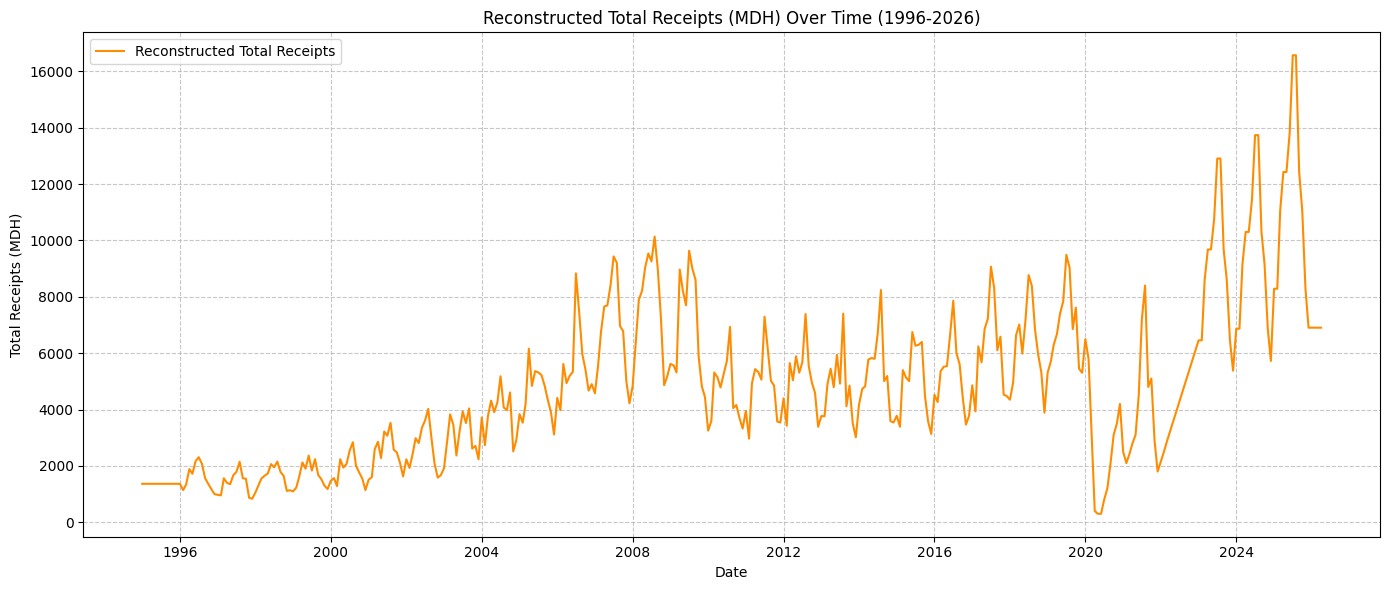

In [21]:
# 6. Plot the new 'Total_Receipts_MDH' series
plt.figure(figsize=(14, 6))
plt.plot(merged_df['Date'], merged_df['Total_Receipts_MDH'], color='darkorange', label='Reconstructed Total Receipts')
plt.title('Reconstructed Total Receipts (MDH) Over Time (1996-2026)')
plt.xlabel('Date')
plt.ylabel('Total Receipts (MDH)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

# Filtrage des données non nulles pour les tests
data_test =  full_tourisme_data['Arrivals'].dropna()

print("--- Test de Dickey-Fuller Augmenté (ADF) ---")
adf_result = adfuller(data_test)
print(f'Statistique ADF : {adf_result[0]}')
print(f'p-value : {adf_result[1]}')
print('Stationnaire (ADF)' if adf_result[1] < 0.05 else 'Non stationnaire (ADF)')

print("\n--- Test KPSS ---")
kpss_result = kpss(data_test, regression='c', nlags='auto')
print(f'Statistique KPSS : {kpss_result[0]}')
print(f'p-value : {kpss_result[1]}')
print('Stationnaire (KPSS)' if kpss_result[1] > 0.05 else 'Non stationnaire (KPSS)')

print("\n--- Test de Phillips-Perron (PP) ---")
pp_test = PhillipsPerron(data_test)

# Correction : Utilisation des attributs stat et pvalue au lieu de l'indexation
print(f'Statistique PP : {pp_test.stat}')
print(f'p-value : {pp_test.pvalue}')
if pp_test.pvalue < 0.05:
    print(f"\nRésultat : p-value ({pp_test.pvalue:.4f}) < 0.05 -> Stationnaire (PP)")
else:
    print(f"\nRésultat : p-value ({pp_test.pvalue:.4f}) >= 0.05 -> Non stationnaire (PP)")

--- Test de Dickey-Fuller Augmenté (ADF) ---
Statistique ADF : -1.2721580526791334
p-value : 0.6418118535723852
Non stationnaire (ADF)

--- Test KPSS ---
Statistique KPSS : 1.8422304351352623
p-value : 0.01
Non stationnaire (KPSS)

--- Test de Phillips-Perron (PP) ---
Statistique PP : -6.58126711788471
p-value : 7.503911039791613e-09

Résultat : p-value (0.0000) < 0.05 -> Stationnaire (PP)


/tmp/ipykernel_6915/682304548.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(data_test, regression='c', nlags='auto')


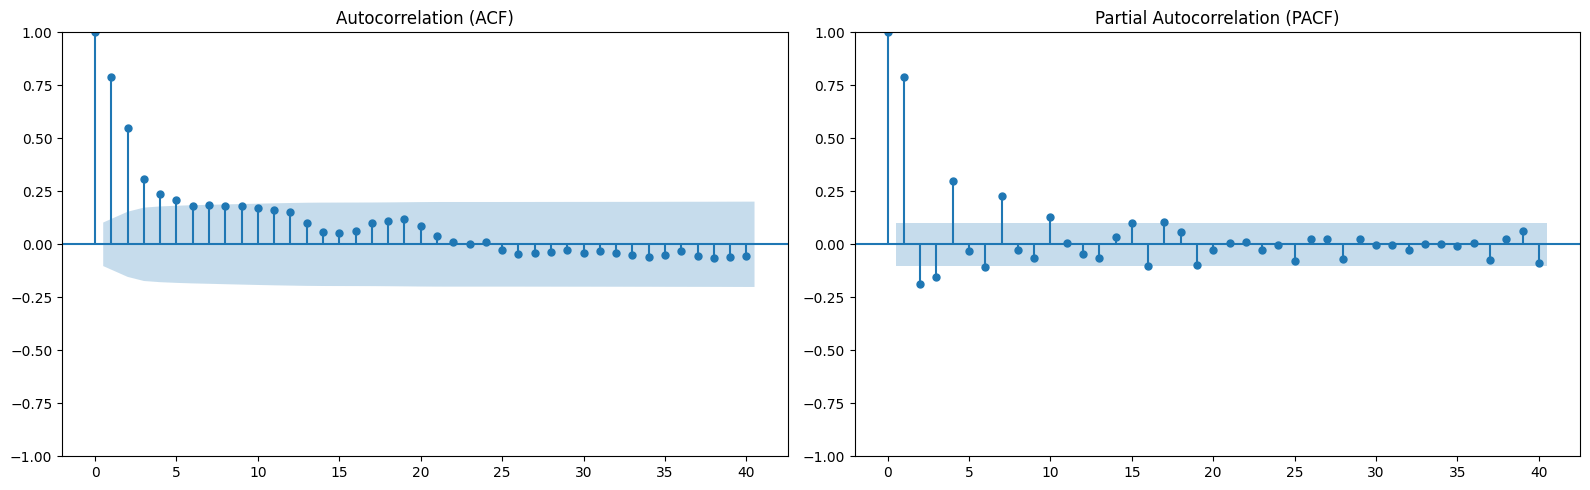

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

# Define y here to ensure it's available for plotting
y = np.log1p(merged_df['Arrivals'])

# Filter out NaN values if any remain for the plotting
y_clean = y.dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot ACF
plot_acf(y_clean, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# Plot PACF
plot_pacf(y_clean, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

Transformation log(1+x) appliquée pour gérer les valeurs nulles.


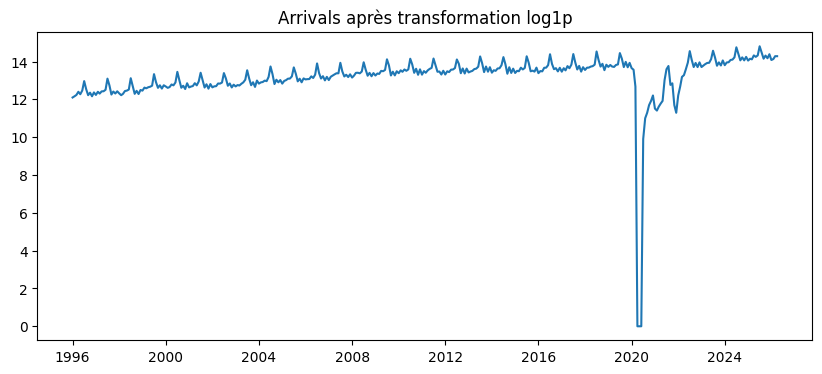

In [24]:
# Transformation pour stabiliser la variance
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

# Note : Box-Cox nécessite des données strictement positives (> 0).
# Comme nous avons des zéros en 2020, on utilise log1p (log(1+x)) ou on ajoute une constante.

y = np.log1p(merged_df['Arrivals'])

print('Transformation log(1+x) appliquée pour gérer les valeurs nulles.')
plt.figure(figsize=(10, 4))
plt.plot(merged_df['Date'], y)
plt.title('Arrivals après transformation log1p')
plt.show()

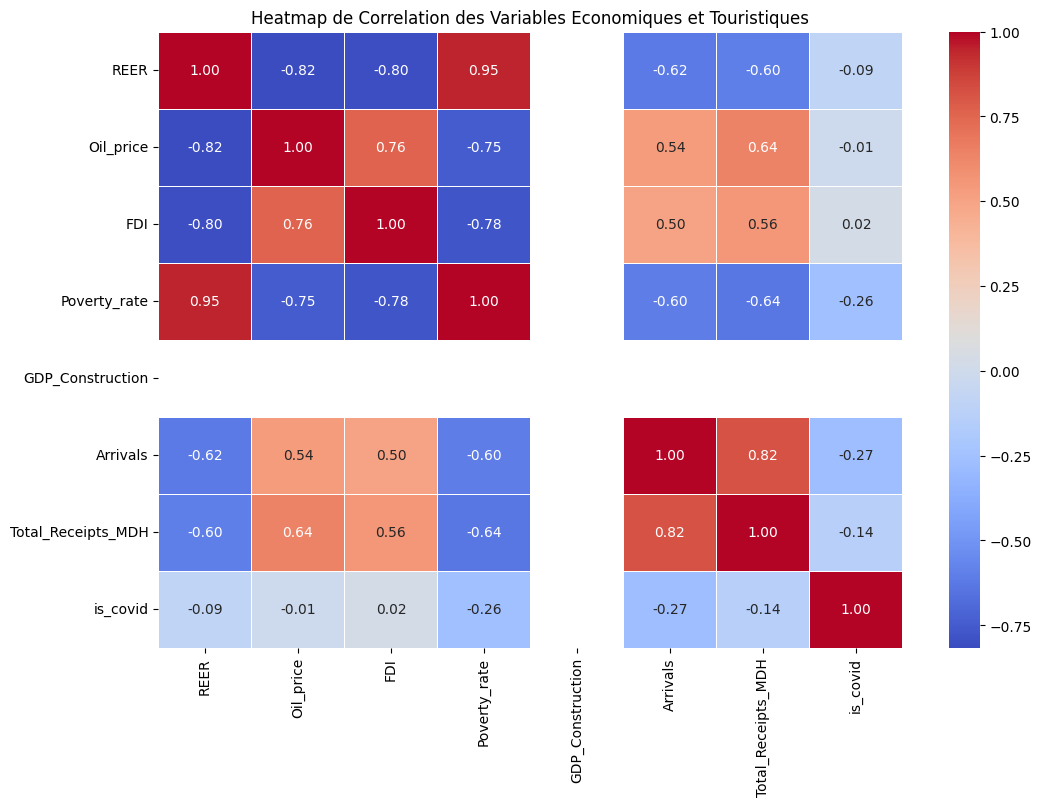

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selection des colonnes numeriques pertinentes
corr_columns = ['REER', 'Oil_price', 'FDI', 'Poverty_rate', 'GDP_Construction', 'Arrivals', 'Total_Receipts_MDH', 'is_covid']
corr_matrix = merged_df[corr_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlation des Variables Economiques et Touristiques')
plt.show()

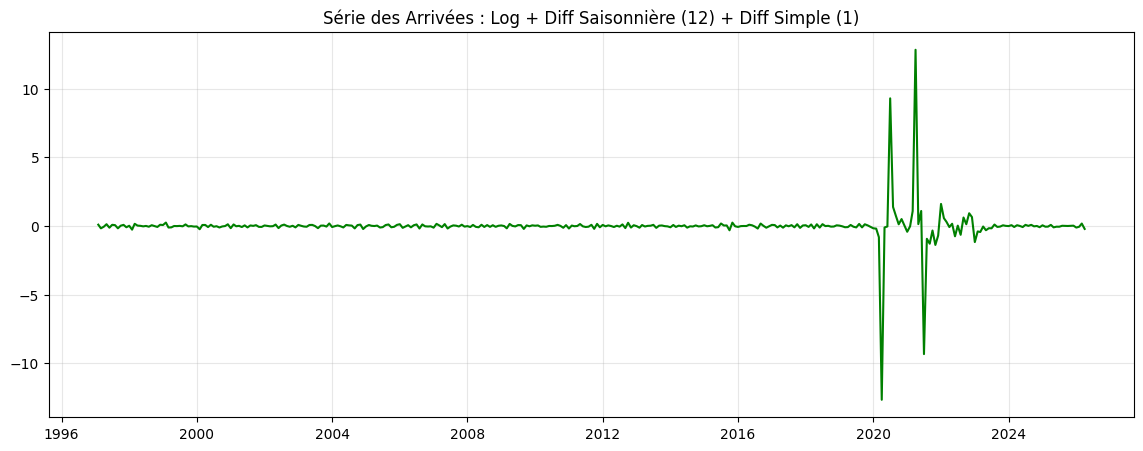

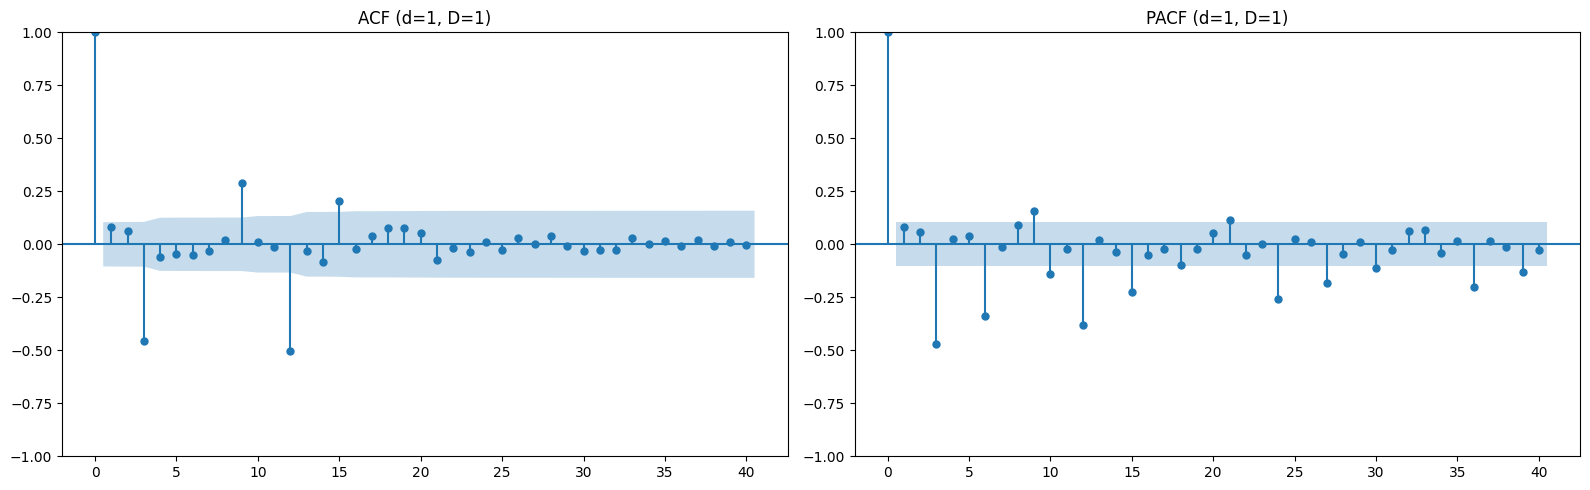

In [26]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Création de la différenciation annuelle (D=1, m=12) sur la série log-transformée
merged_df['log_Arrivals'] = y # y contient déjà log1p(Arrivals)
merged_df['log_Arrivals_diff12'] = merged_df['log_Arrivals'].diff(12)

# 2. Création de la différenciation simple (d=1) pour stabiliser la tendance
merged_df['log_Arrivals_diff12_1'] = merged_df['log_Arrivals_diff12'].diff(1)

# Nettoyage des valeurs NaN pour l'affichage
y_diff_final = merged_df['log_Arrivals_diff12_1'].dropna()

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(merged_df['Date'].loc[y_diff_final.index], y_diff_final, color='green')
plt.title('Série des Arrivées : Log + Diff Saisonnière (12) + Diff Simple (1)')
plt.grid(True, alpha=0.3)
plt.show()

# Graphiques ACF et PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(y_diff_final, lags=40, ax=axes[0])
axes[0].set_title('ACF (d=1, D=1)')
plot_pacf(y_diff_final, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (d=1, D=1)')
plt.tight_layout()
plt.show()

✅ P-value ADF après double différenciation : 0.00000
La série est PARFAITEMENT STATIONNAIRE. On peut lire l'ACF/PACF.


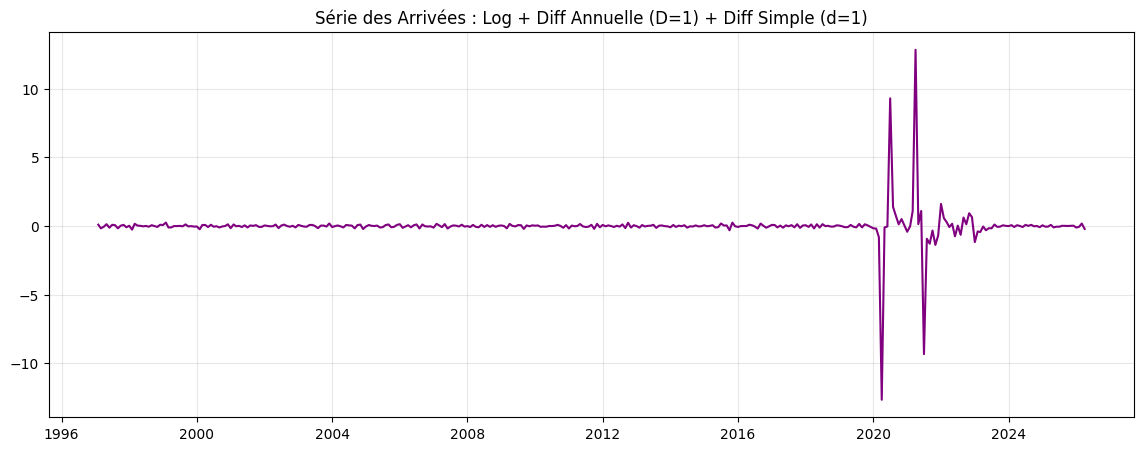

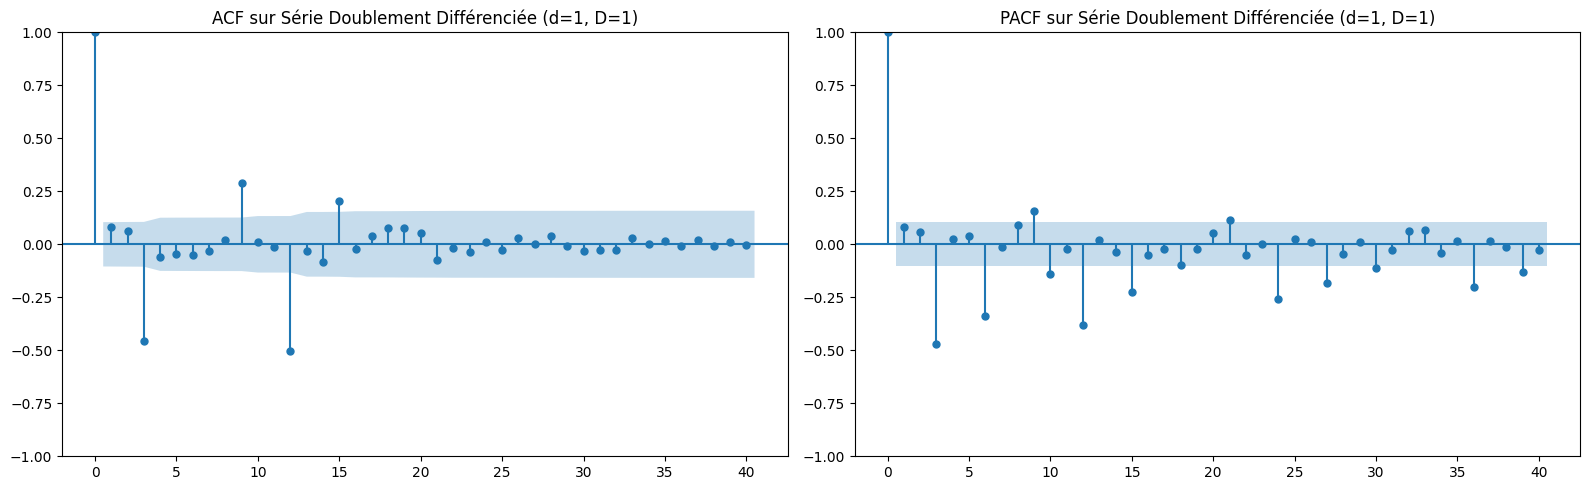

In [27]:
y_diff_both = y.diff(12).diff(1).dropna()

# 2. TEST DE STATIONNARITÉ FINAL (ADF)
resultat_adf = adfuller(y_diff_both)
print(f"✅ P-value ADF après double différenciation : {resultat_adf[1]:.5f}")
if resultat_adf[1] < 0.05:
    print("La série est PARFAITEMENT STATIONNAIRE. On peut lire l'ACF/PACF.")
else:
    print("Attention, la série n'est toujours pas stationnaire.")

# 3. VISUALISATION DE LA SÉRIE FINALE
plt.figure(figsize=(14, 5))
plt.plot(merged_df['Date'].loc[y_diff_both.index], y_diff_both, color='purple')
plt.title('Série des Arrivées : Log + Diff Annuelle (D=1) + Diff Simple (d=1)')
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(y_diff_both, lags=40, ax=axes[0])
axes[0].set_title('ACF sur Série Doublement Différenciée (d=1, D=1)')

plot_pacf(y_diff_both, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF sur Série Doublement Différenciée (d=1, D=1)')

plt.tight_layout()
plt.show()

## Split des donnees


In [28]:
# 1. Préparation et Split Train/Test
# Utilisation de log1p
y_series = merged_df.set_index('Date')['Arrivals'].apply(lambda x: np.log1p(x)).dropna()

test_start_date = '2023-01-01'
train = y_series[y_series.index < test_start_date]
test = y_series[y_series.index >= test_start_date]
test_size = len(test)

# Initialize exog_source before using it
exog_source = pd.DataFrame(index=y_series.index)
exog_source['Covid_shock'] = 0
# On active le choc Covid (1) de Mars 2020 à Décembre 2021
exog_source.loc['2020-03-01':'2021-12-01', 'Covid_shock'] = 1

# On sépare l'exogène pour le Train et le Test
exog_train = exog_source.loc[train.index]
exog_test = exog_source.loc[test.index]
print(f"Taille du Train : {len(train)} mois")
print(f"Taille du Test (Post-Covid) : {len(test)} mois")

Taille du Train : 324 mois
Taille du Test (Post-Covid) : 40 mois


## SARIMAX

In [29]:
import statsmodels.api as sm
from sklearn.metrics import r2_score

# --- 1. On utilise les données BRUTES (pas de log1p) ---
# Assurez-vous que merged_df a bien un index datetime
y_brut = merged_df.set_index('Date')['Arrivals'].dropna()

train_brut = y_brut[y_brut.index < test_start_date]
test_brut = y_brut[y_brut.index >= test_start_date]

print("Entraînement du modèle de référence sur données brutes...")

# --- 2. Modèle très simplifié pour forcer la stabilité ---
# On enlève la partie (1,0,3) complexe pour l'instant.
modele_test = sm.tsa.statespace.SARIMAX(
    train_brut,
    exog=exog_train,
    order=(1, 0, 0),             # Un modèle très simple (AR 1 uniquement)
    seasonal_order=(0, 1, 1, 12) # Votre saisonnalité confirmée par l'ACF
    # Note: On laisse statsmodels appliquer ses sécurités par défaut
)

resultats_test = modele_test.fit(disp=False)

# --- 3. Prédictions Directes ---
predictions_brutes = resultats_test.forecast(steps=len(test_brut), exog=exog_test)

# --- 4. Calcul du R2 (sans expm1 car on n'a pas mis de log) ---
r2_test = r2_score(test_brut, predictions_brutes)
print(f"\nScore R2 (Test sans Log) : {r2_test:.4f}")

Entraînement du modèle de référence sur données brutes...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Score R2 (Test sans Log) : -0.8448


In [30]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.7 MB/s eta 0:00:00


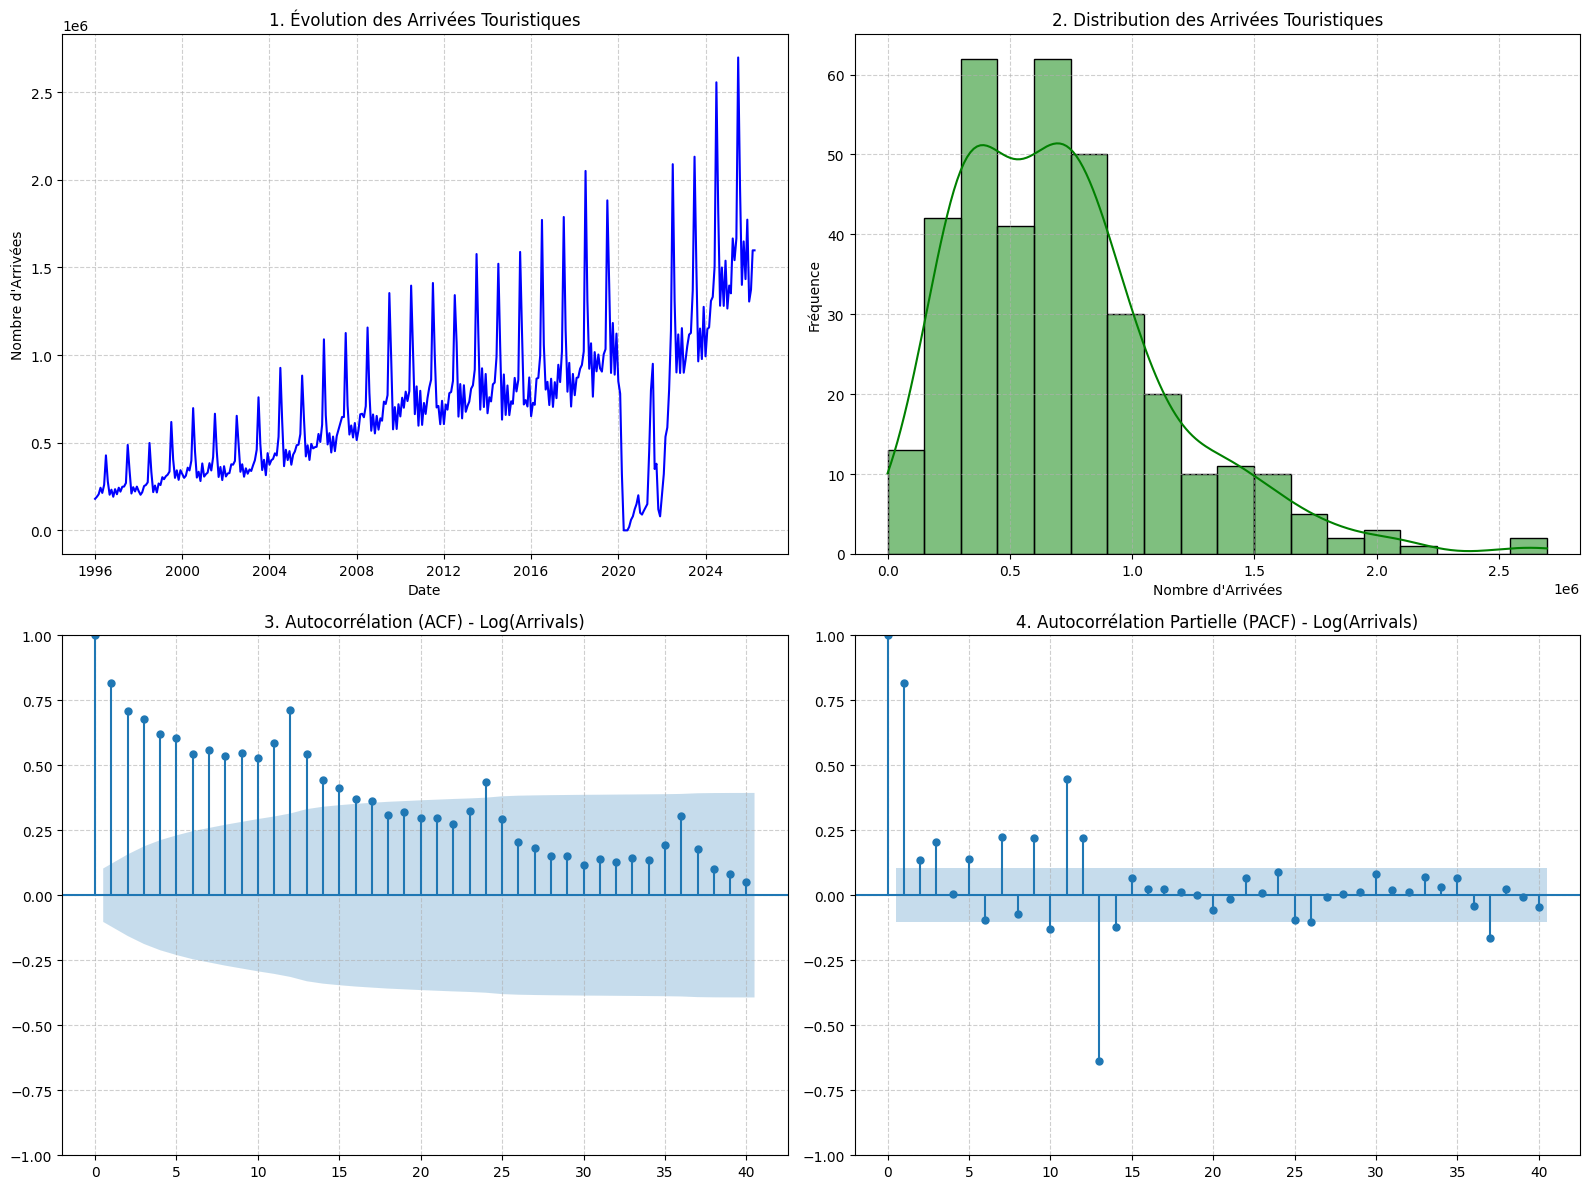

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure 'Date' is datetime and set as index for plotting if not already
# (Assuming merged_df is already prepared as in previous cells)
if 'Date' in merged_df.columns:
    merged_df['Date'] = pd.to_datetime(merged_df['Date'])
    temp_df_plot = merged_df.set_index('Date').copy()
else:
    temp_df_plot = merged_df.copy()

# Ensure the 'Arrivals' column is available and handle NaNs for plotting
series_for_plots = temp_df_plot['Arrivals'].dropna()

# Use the log1p transformed series for ACF/PACF as it's often more stable
# The 'y_series' variable from previous cells (log1p of Arrivals) is suitable.
# If 'y_series' is not directly available, create it here.
if 'y_series' not in locals():
    y_series = np.log1p(merged_df.set_index('Date')['Arrivals'].dropna())

# Create a figure and a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Evolution de la série temporelle (Line plot)
axes[0, 0].plot(series_for_plots.index, series_for_plots, color='blue', linewidth=1.5)
axes[0, 0].set_title('1. Évolution des Arrivées Touristiques')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Nombre d\'Arrivées')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Histogramme de la distribution avec KDE
sns.histplot(series_for_plots, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('2. Distribution des Arrivées Touristiques')
axes[0, 1].set_xlabel('Nombre d\'Arrivées')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Autocorrélation (ACF) - Using the log-transformed series for better interpretability
plot_acf(y_series, lags=40, ax=axes[1, 0], title='3. Autocorrélation (ACF) - Log(Arrivals)')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Plot 4: Autocorrélation Partielle (PACF) - Using the log-transformed series
plot_pacf(y_series, lags=40, ax=axes[1, 1], method='ywm', title='4. Autocorrélation Partielle (PACF) - Log(Arrivals)')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

Recherche automatique du meilleur modèle SARIMAX...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=8913.712, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=8683.574, Time=1.20 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=8737.876, Time=1.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=10455.946, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=8898.650, Time=0.10 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=8682.802, Time=2.39 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=8674.495, Time=5.26 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=8673.442, Time=2.90 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=8745.107, Time=1.56 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=8672.436, Time=6.79 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=8719.234, Time=2.32 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=8672.987, Time=6.81 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=8687.739, Time=4.82 sec
 ARIMA(2,1,0)(1,0,2)[12] intercep

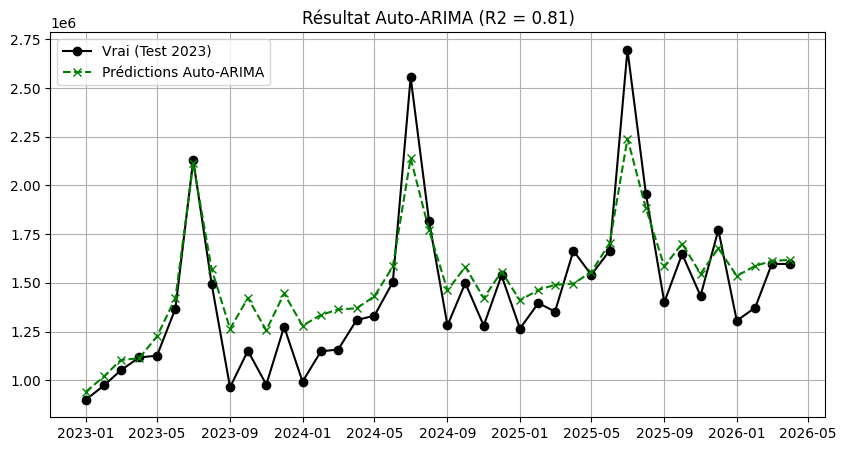

In [31]:
import pmdarima as pm
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
h
print("Recherche automatique du meilleur modèle SARIMAX...")

# 1. L'algorithme cherche la meilleure combinaison possible
# Il va tester différents p, d, q et P, D, Q de lui-même
auto_modele = pm.auto_arima(
    train_brut,
    X=exog_train,          # On garde l'information du choc Covid
    seasonal=True, m=12,   # On lui dit qu'il y a 12 mois dans l'année
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    trace=True,            # Affiche les tests en temps réel
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True          # Rend la recherche plus intelligente et rapide
)

print("\n--- MEILLEUR MODÈLE TROUVÉ ---")
print(auto_modele.summary())

# 2. Prédictions directes avec le meilleur modèle
predictions_auto = auto_modele.predict(n_periods=len(test_brut), X=exog_test)

# 3. Calcul du R2
r2_auto = r2_score(test_brut, predictions_auto)
print(f"\nNouveau Score R2 : {r2_auto:.4f}")

# 4. Visualisation
plt.figure(figsize=(10, 5))
plt.plot(test_brut.index, test_brut, label='Vrai (Test 2023)', color='black', marker='o')
plt.plot(test_brut.index, predictions_auto, label='Prédictions Auto-ARIMA', color='green', linestyle='--', marker='x')
plt.title(f"Résultat Auto-ARIMA (R2 = {r2_auto:.2f})")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    # R-squared (R²)
    r2 = r2_score(y_true, y_pred)

    # Mean Absolute Percentage Error (MAPE)
    # Avoid division by zero by replacing 0 with a small epsilon
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, np.finfo(float).eps))) * 100

    return {
        "RMSE": rmse,
        "MAPE": mape,
        "MAE": mae,
        "R2": r2
    }


In [33]:
# Calcul des métriques pour le modèle Auto-ARIMA
metrics_auto_arima = evaluate_model(test_brut, predictions_auto)

print("--- Métriques d'évaluation pour le modèle SARIMAX (Auto-ARIMA) ---")
for metric, value in metrics_auto_arima.items():
    print(f"{metric}: {value:.4f}")

--- Métriques d'évaluation pour le modèle SARIMAX (Auto-ARIMA) ---
RMSE: 170084.0221
MAPE: 9.6753
MAE: 131218.1172
R2: 0.8065


Entraînement du modèle ARIMA(2,1,3) + Fourier sur données brutes...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Score R2 (ARIMA + Fourier) : -0.4402


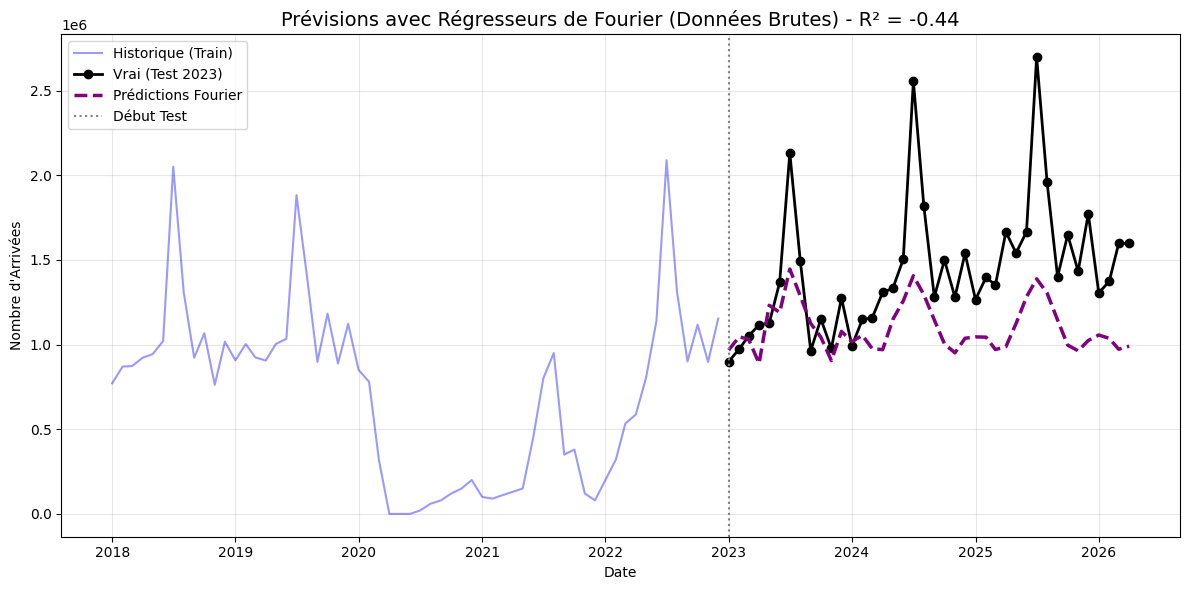

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score

# --- 1. La Fonction de Fourier Sécurisée ---
def get_fourier(index, p=12, n=2, t_start=0):
    """
    Génère les ondes de Fourier. t_start garantit la continuité entre Train et Test.
    """
    t = np.arange(t_start, t_start + len(index))
    x = 2 * np.pi * t / p
    cols = []
    for i in range(1, n + 1):
        cols.append(np.sin(i * x))
        cols.append(np.cos(i * x))
    return np.column_stack(cols)

# --- 2. Préparation des Données (SANS LOG) ---
# TRÈS IMPORTANT : On n'utilise plus log1p. On prend les données brutes.
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
y_series = merged_df.set_index('Date')['Arrivals'].dropna()

test_start_date = '2023-01-01'
train = y_series[y_series.index < test_start_date]
test = y_series[y_series.index >= test_start_date]

# --- 3. Création de la variable Covid ---
exog_source = pd.DataFrame(index=y_series.index)
exog_source['Covid_shock'] = 0
exog_source.loc['2020-03-01':'2021-12-01', 'Covid_shock'] = 1

exog_train = exog_source.loc[train.index]
exog_test = exog_source.loc[test.index]

# --- 4. Création des Variables Exogènes Combinées (Covid + Fourier) ---
# Génération de Fourier pour le Train (commence à 0)
fourier_train = get_fourier(train.index, p=12, n=2, t_start=0)

# Génération de Fourier pour le Test (continue après le Train)
t_end_train = len(train)
fourier_test = get_fourier(test.index, p=12, n=2, t_start=t_end_train)

# On colle la colonne Covid_shock avec les colonnes de Fourier
exog_combined_train = np.column_stack((exog_train['Covid_shock'].values[:, None], fourier_train))
exog_combined_test  = np.column_stack((exog_test['Covid_shock'].values[:, None], fourier_test))

# --- 5. Modèle ARIMA + Fourier ---
print("Entraînement du modèle ARIMA(2,1,3) + Fourier sur données brutes...")

modele_fourier = sm.tsa.statespace.SARIMAX(
    train,
    exog=exog_combined_train,
    order=(2, 1, 3),             # Le d=1 ne posera plus de problème sans le log !
    seasonal_order=(0, 0, 0, 0), # Désactivé car Fourier s'en occupe
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultats_fourier = modele_fourier.fit(disp=False)

# --- 6. Prédictions ---
predictions_fourier = resultats_fourier.forecast(steps=len(test), exog=exog_combined_test)

# --- 7. Calcul du R2 (Direct, SANS expm1) ---
# Comme on n'a pas mis de log, on compare directement test et predictions
r2 = r2_score(test, predictions_fourier)
print(f"\nScore R2 (ARIMA + Fourier) : {r2:.4f}")

# --- 8. Visualisation ---
plt.figure(figsize=(12, 6))

# On affiche un peu de l'historique récent (Train) pour voir la continuité
historique_recent = train.loc['2018-01-01':]
plt.plot(historique_recent.index, historique_recent, label='Historique (Train)', color='blue', alpha=0.4)

# Affichage du Test et de la Prédiction
plt.plot(test.index, test, label='Vrai (Test 2023)', color='black', marker='o', linewidth=2)
plt.plot(predictions_fourier.index, predictions_fourier, label='Prédictions Fourier', color='purple', linestyle='--', linewidth=2.5)

# Ligne verticale pour marquer le début du test
plt.axvline(x=pd.to_datetime(test_start_date), color='gray', linestyle=':', label='Début Test')

plt.title(f"Prévisions avec Régresseurs de Fourier (Données Brutes) - R² = {r2:.2f}", fontsize=14)
plt.xlabel('Date')
plt.ylabel('Nombre d\'Arrivées')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

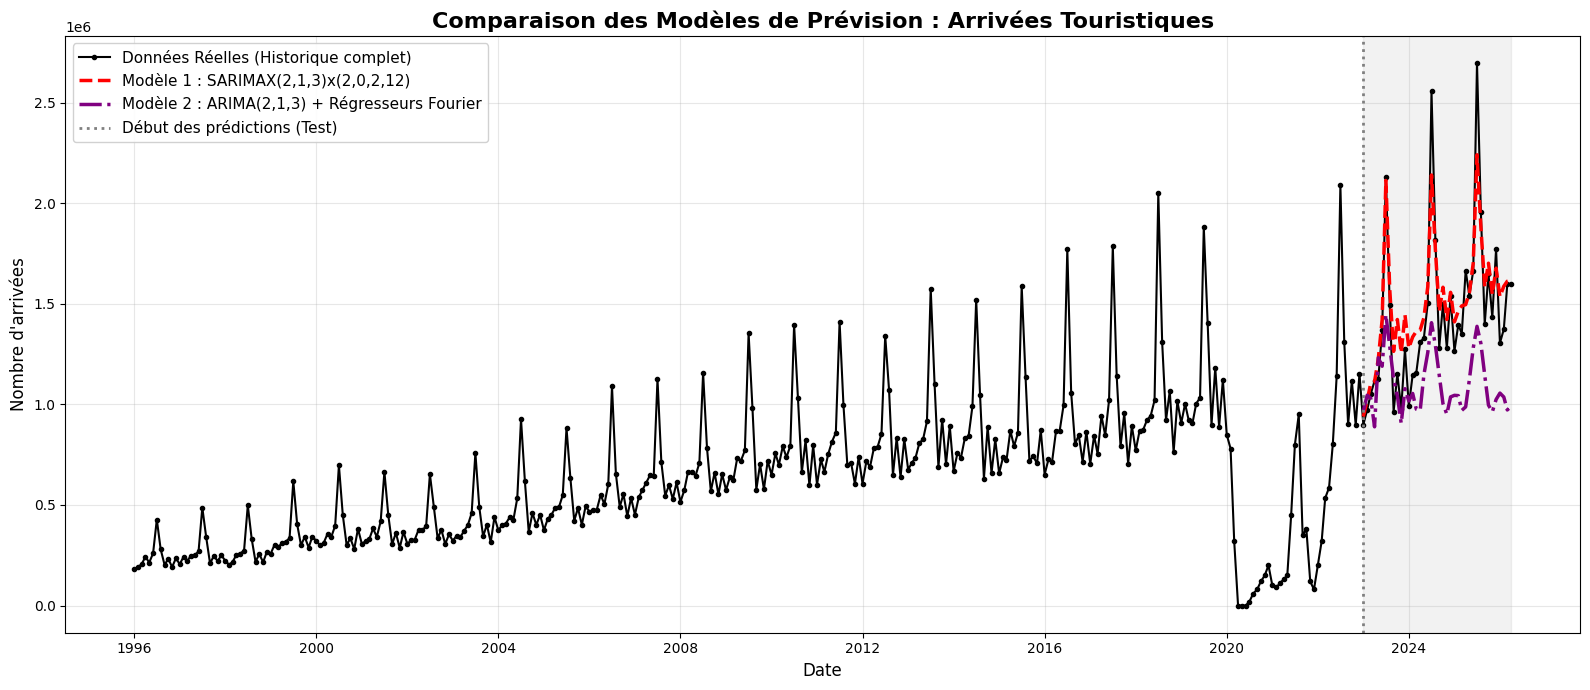

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Préparation des données réelles (Toute la série) ---
# On reprend y_series (qui contient tout : train + test) et on annule le log
y_full_reel = y_series.copy() # Fixed: y_series is already on the original scale, no need for expm1

# --- 2. Préparation des prédictions (Assurez-vous d'avoir ces variables) ---
# Remplacez "predictions_champion" et "predictions_fourier" par les noms exacts de vos variables
valeurs_predites_champion = predictions_auto # Corrected: predictions_auto is already on original scale
valeurs_predites_fourier = predictions_fourier # Corrected: predictions_fourier is already on original scale

# --- 3. Création du Graphique ---
plt.figure(figsize=(16, 7)) # Un graphique bien large pour voir toute la série

# A. Tracer TOUTE la série réelle en fond
plt.plot(y_full_reel.index, y_full_reel,
         label='Données Réelles (Historique complet)',
         color='black', linewidth=1.5, marker='.')

# B. Tracer les prédictions du Modèle 1 (Champion Auto-ARIMA)
plt.plot(valeurs_predites_champion.index, valeurs_predites_champion,
         label='Modèle 1 : SARIMAX(2,1,3)x(2,0,2,12)',
         color='red', linestyle='--', linewidth=2.5)

# C. Tracer les prédictions du Modèle 2 (Fourier)
plt.plot(valeurs_predites_fourier.index, valeurs_predites_fourier,
         label='Modèle 2 : ARIMA(2,1,3) + Régresseurs Fourier',
         color='purple', linestyle='-.', linewidth=2.5)

# --- 4. Ajout d'une ligne de séparation (Train vs Test) ---
# On trace une ligne verticale grise à la date où commence le Test (ex: 1er Janvier 2023)
date_separation = pd.to_datetime(test_start_date)
plt.axvline(x=date_separation, color='gray', linestyle=':', linewidth=2,
            label='Début des prédictions (Test)')

# Optionnel : Griser légèrement la zone de test pour la mettre en valeur
plt.axvspan(date_separation, y_full_reel.index[-1], color='gray', alpha=0.1)

# --- 5. Mise en forme et Affichage ---
plt.title('Comparaison des Modèles de Prévision : Arrivées Touristiques', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Nombre d\'arrivées', fontsize=12)

# Positionner la légende joliment
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
# Drop the temporary transformation columns
merged_df = merged_df.drop(columns=['log_Arrivals', 'log_Arrivals_diff12', 'log_Arrivals_diff12_1'], errors='ignore')

print("Columns 'log_Arrivals', 'log_Arrivals_diff12', and 'log_Arrivals_diff12_1' have been dropped.")
display(merged_df.head())

Columns 'log_Arrivals', 'log_Arrivals_diff12', and 'log_Arrivals_diff12_1' have been dropped.


,Date,InterTourismeReceipts,REER,Oil_price,FDI,Poverty_rate,GDP_Construction,Year,Month,Nights,is_covid,Arrivals,Total_Receipts_MDH
0,1995-01-01,1.469000e+09,109.375670,17.015000,3.347683e+08,15.500000,NaN,1995,1,NaN,0,NaN,1363.879141
1,1995-02-01,1.501953e+09,109.404721,17.050000,3.366899e+08,15.542466,NaN,1995,2,NaN,0,NaN,1363.879141
2,1995-03-01,1.531718e+09,109.430960,16.850000,3.384256e+08,15.580822,NaN,1995,3,NaN,0,NaN,1363.879141
3,1995-04-01,1.564671e+09,109.460011,18.135738,3.403472e+08,15.623288,NaN,1995,4,NaN,0,NaN,1363.879141
4,1995-05-01,1.596562e+09,109.488125,19.380000,3.422068e+08,15.664384,NaN,1995,5,NaN,0,NaN,1363.879141


In [37]:
import os

# Utilisation du chemin Drive déjà défini au début du notebook
save_path = '/content/gdrive/MyDrive/Time series Projet/data'

if os.path.exists(save_path):
    # Sauvegarde du dataset principal fusionné
    merged_df.to_csv(os.path.join(save_path, 'merged_tourism_data_final.csv'), index=False)

    # Sauvegarde des métriques de performance
    metrics_df.to_csv(os.path.join(save_path, 'model_performance_metrics.csv'), index=False)

    print(f"Succès : Les fichiers ont été sauvegardés dans {save_path}")
    print("Fichiers créés : merged_tourism_data_final.csv, model_performance_metrics.csv")
else:
    print(f"Erreur : Le dossier {save_path} n'est pas accessible.")

NameError: name 'metrics_df' is not defined